# Phần 1. Cài đặt thư viện và thiết lập giao diện biểu đồ

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Thiết lập style
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Bảng màu nhất quán: Xanh lá cho No, Đỏ cho Yes
palette_disease = ['#2ecc71', '#e74c3c']
# Bảng màu cho các thuộc tính khác
palette_set2 = "Set2"

In [3]:
# Đọc dữ liệu
url = "/content/drive/MyDrive/Data Mining/Project/disease_prediction_2026.csv"
df = pd.read_csv(url)

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (1000, 14)


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79.0,28.5,73.0,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77.0,33.9,71.0,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71.0,27.2,79.0,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82.0,21.5,61.0,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75.0,23.3,73.0,Yes,No,Low,Yes,Yes


In [4]:
# Bỏ cột patient_id vì nó là mã số định danh, không có giá trị phân tích
df = df.drop('patient_id', axis=1)

# Xác định các loại cột tự động
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns.drop('disease') # Bỏ target ra khỏi thuộc tính đầu vào

print("Các cột số:", list(num_cols))
print("Các cột phân loại:", list(cat_cols))

Các cột số: ['age', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate']
Các cột phân loại: ['gender', 'smoking', 'alcohol_consumption', 'physical_activity', 'family_history']


# Phần 2. Kiểm tra dữ liệu và tiền xử lý

## 2.1 Kiểm tra giá trị khuyết và lỗi nhập liệu

In [5]:
# Kiểm tra kiểu dữ liệu và missing values
print("--- THÔNG TIN DỮ LIỆU ---")
df.info()

--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1000 non-null   int64  
 1   gender               1000 non-null   object 
 2   glucose_mg_dl        1000 non-null   int64  
 3   cholesterol_mg_dl    1000 non-null   int64  
 4   systolic_bp          1000 non-null   int64  
 5   diastolic_bp         999 non-null    float64
 6   bmi                  1000 non-null   float64
 7   heart_rate           999 non-null    float64
 8   smoking              1000 non-null   object 
 9   alcohol_consumption  1000 non-null   object 
 10  physical_activity    1000 non-null   object 
 11  family_history       1000 non-null   object 
 12  disease              1000 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 101.7+ KB


In [6]:
print("\n--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT (MISSING VALUES) ---")
print(df.isnull().sum())


--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT (MISSING VALUES) ---
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           1
bmi                    0
heart_rate             1
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64


In [7]:
print("\n--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) ---")
display(df.describe().T)


--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) ---


,count,mean,std,min,25%,50%,75%,max
age,1000.0,51.649000,24.585163,18.0,33.0,53.0,69.00,510.0
glucose_mg_dl,1000.0,105.163000,40.528002,30.0,87.0,105.0,121.25,1111.0
cholesterol_mg_dl,1000.0,210.014000,39.749111,89.0,183.0,210.5,235.25,339.0
systolic_bp,1000.0,123.893000,18.701211,67.0,111.0,124.0,135.00,195.0
diastolic_bp,999.0,81.032032,9.974967,49.0,74.0,81.0,88.00,113.0
bmi,1000.0,26.093000,4.758282,16.0,22.9,26.0,29.30,41.5
heart_rate,999.0,75.974975,9.905484,47.0,70.0,76.0,83.00,114.0


## 2.1. Trực quan hóa tính nhất quán của dữ liệu


### 2.1.1. Dữ liệu phân loại

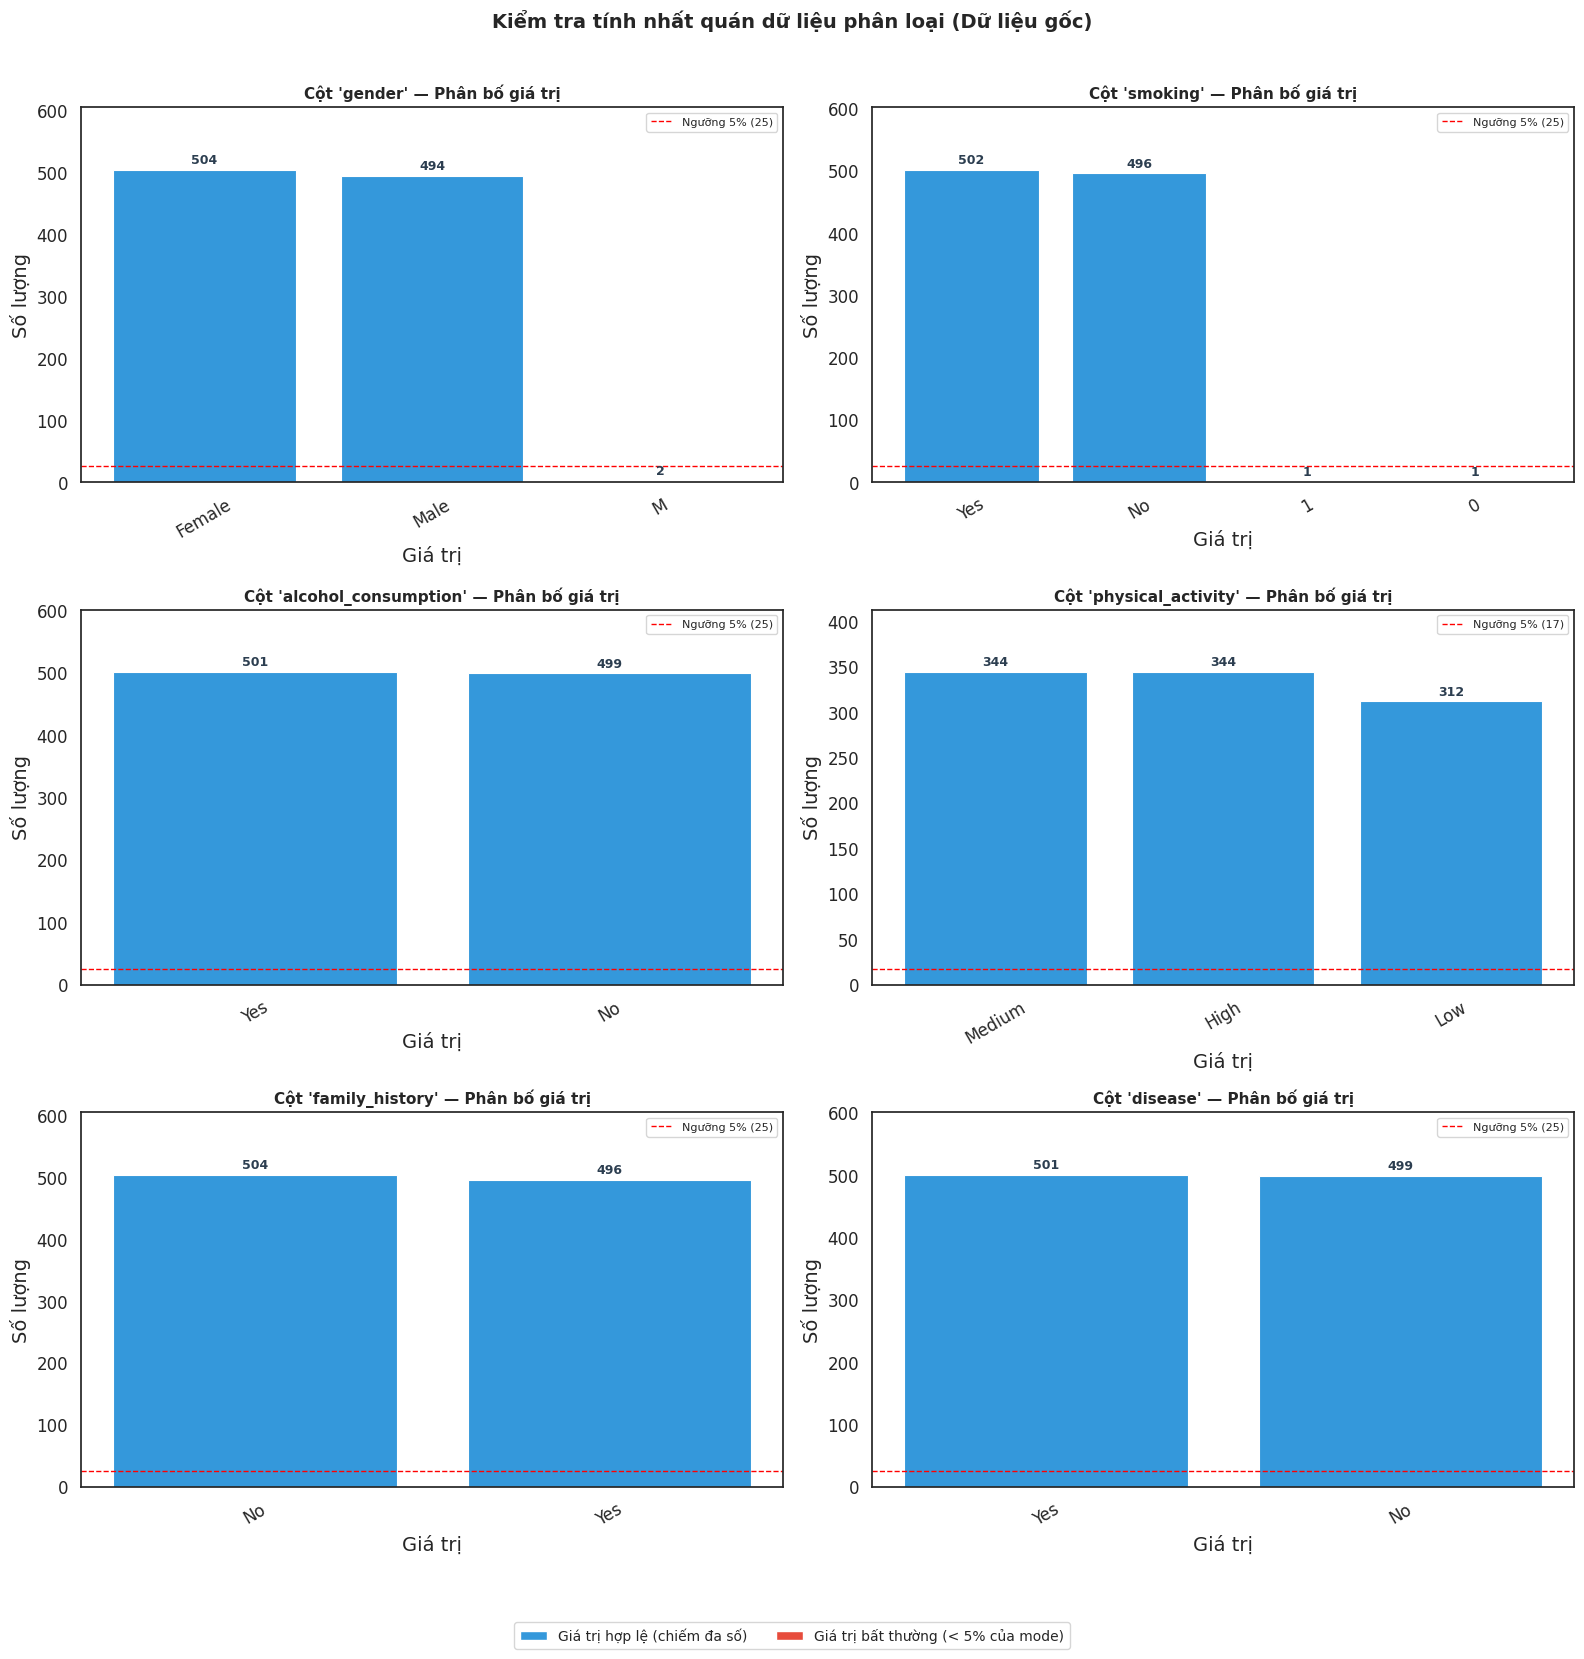


--- TÓM TẮT CÁC GIÁ TRỊ BẤT THƯỜNG PHÁT HIỆN ---
  [gender]: Giá trị bất thường: {'M': np.int64(2)}
  [smoking]: Giá trị bất thường: {'1': np.int64(1), '0': np.int64(1)}
  [alcohol_consumption]: OK — Không có giá trị bất thường
  [physical_activity]: OK — Không có giá trị bất thường
  [family_history]: OK — Không có giá trị bất thường
  [disease]: OK — Không có giá trị bất thường


In [9]:
# Biểu đồ kiểm tra tính nhất quán dữ liệu phân loại (trên dữ liệu GỐC trước khi clean)
from matplotlib.patches import Patch

raw_cat_cols = ['gender', 'smoking', 'alcohol_consumption', 'physical_activity', 'family_history', 'disease']

n_cat = len(raw_cat_cols)
fig, axes = plt.subplots(int(np.ceil(n_cat / 2)), 2,
                         figsize=(16, n_cat * 2.8),
                         constrained_layout=False)
axes = axes.flatten()

for i, col in enumerate(raw_cat_cols):
    ax = axes[i]
    vc = df[col].value_counts(dropna=False).sort_values(ascending=False)
    threshold = vc.max() * 0.05  # Các giá trị < 5% của mode => bất thường

    colors = ['#e74c3c' if v < threshold else '#3498db' for v in vc.values]
    bars = ax.bar(vc.index.astype(str), vc.values, color=colors,
                  edgecolor='white', linewidth=0.8)

    # Tính ylim với padding 20% phía trên để text số không bị cắt
    max_val = vc.max()
    ax.set_ylim(0, max_val * 1.20)

    # Ghi số lượng lên đầu mỗi thanh (căn chỉnh bên trong khoảng padding)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.01,
                str(val), ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#2c3e50')

    ax.set_title(f"Cột '{col}' — Phân bố giá trị", fontweight='bold', fontsize=11)
    ax.set_xlabel("Giá trị")
    ax.set_ylabel("Số lượng")
    ax.tick_params(axis='x', rotation=30)

    # Đường ngưỡng 5%
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1,
               label=f'Ngưỡng 5% ({threshold:.0f})')
    ax.legend(fontsize=8, loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Legend chung ở dưới cùng
legend_elements = [
    Patch(facecolor='#3498db', label='Giá trị hợp lệ (chiếm đa số)'),
    Patch(facecolor='#e74c3c', label='Giá trị bất thường (< 5% của mode)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.0))

plt.suptitle("Kiểm tra tính nhất quán dữ liệu phân loại (Dữ liệu gốc)",
             fontsize=14, fontweight='bold')
# rect=(left, bottom, right, top): để chừa chỗ cho suptitle trên và legend dưới
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

# In tóm tắt bằng text
print("\n--- TÓM TẮT CÁC GIÁ TRỊ BẤT THƯỜNG PHÁT HIỆN ---")
for col in raw_cat_cols:
    vc = df[col].value_counts(dropna=False).sort_values(ascending=False)
    threshold = vc.max() * 0.05
    anomalies = vc[vc < threshold]
    if len(anomalies) > 0:
        print(f"  [{col}]: Giá trị bất thường: {dict(anomalies)}")
    else:
        print(f"  [{col}]: OK — Không có giá trị bất thường")

### 2.2.2. Dữ liệu liên tục

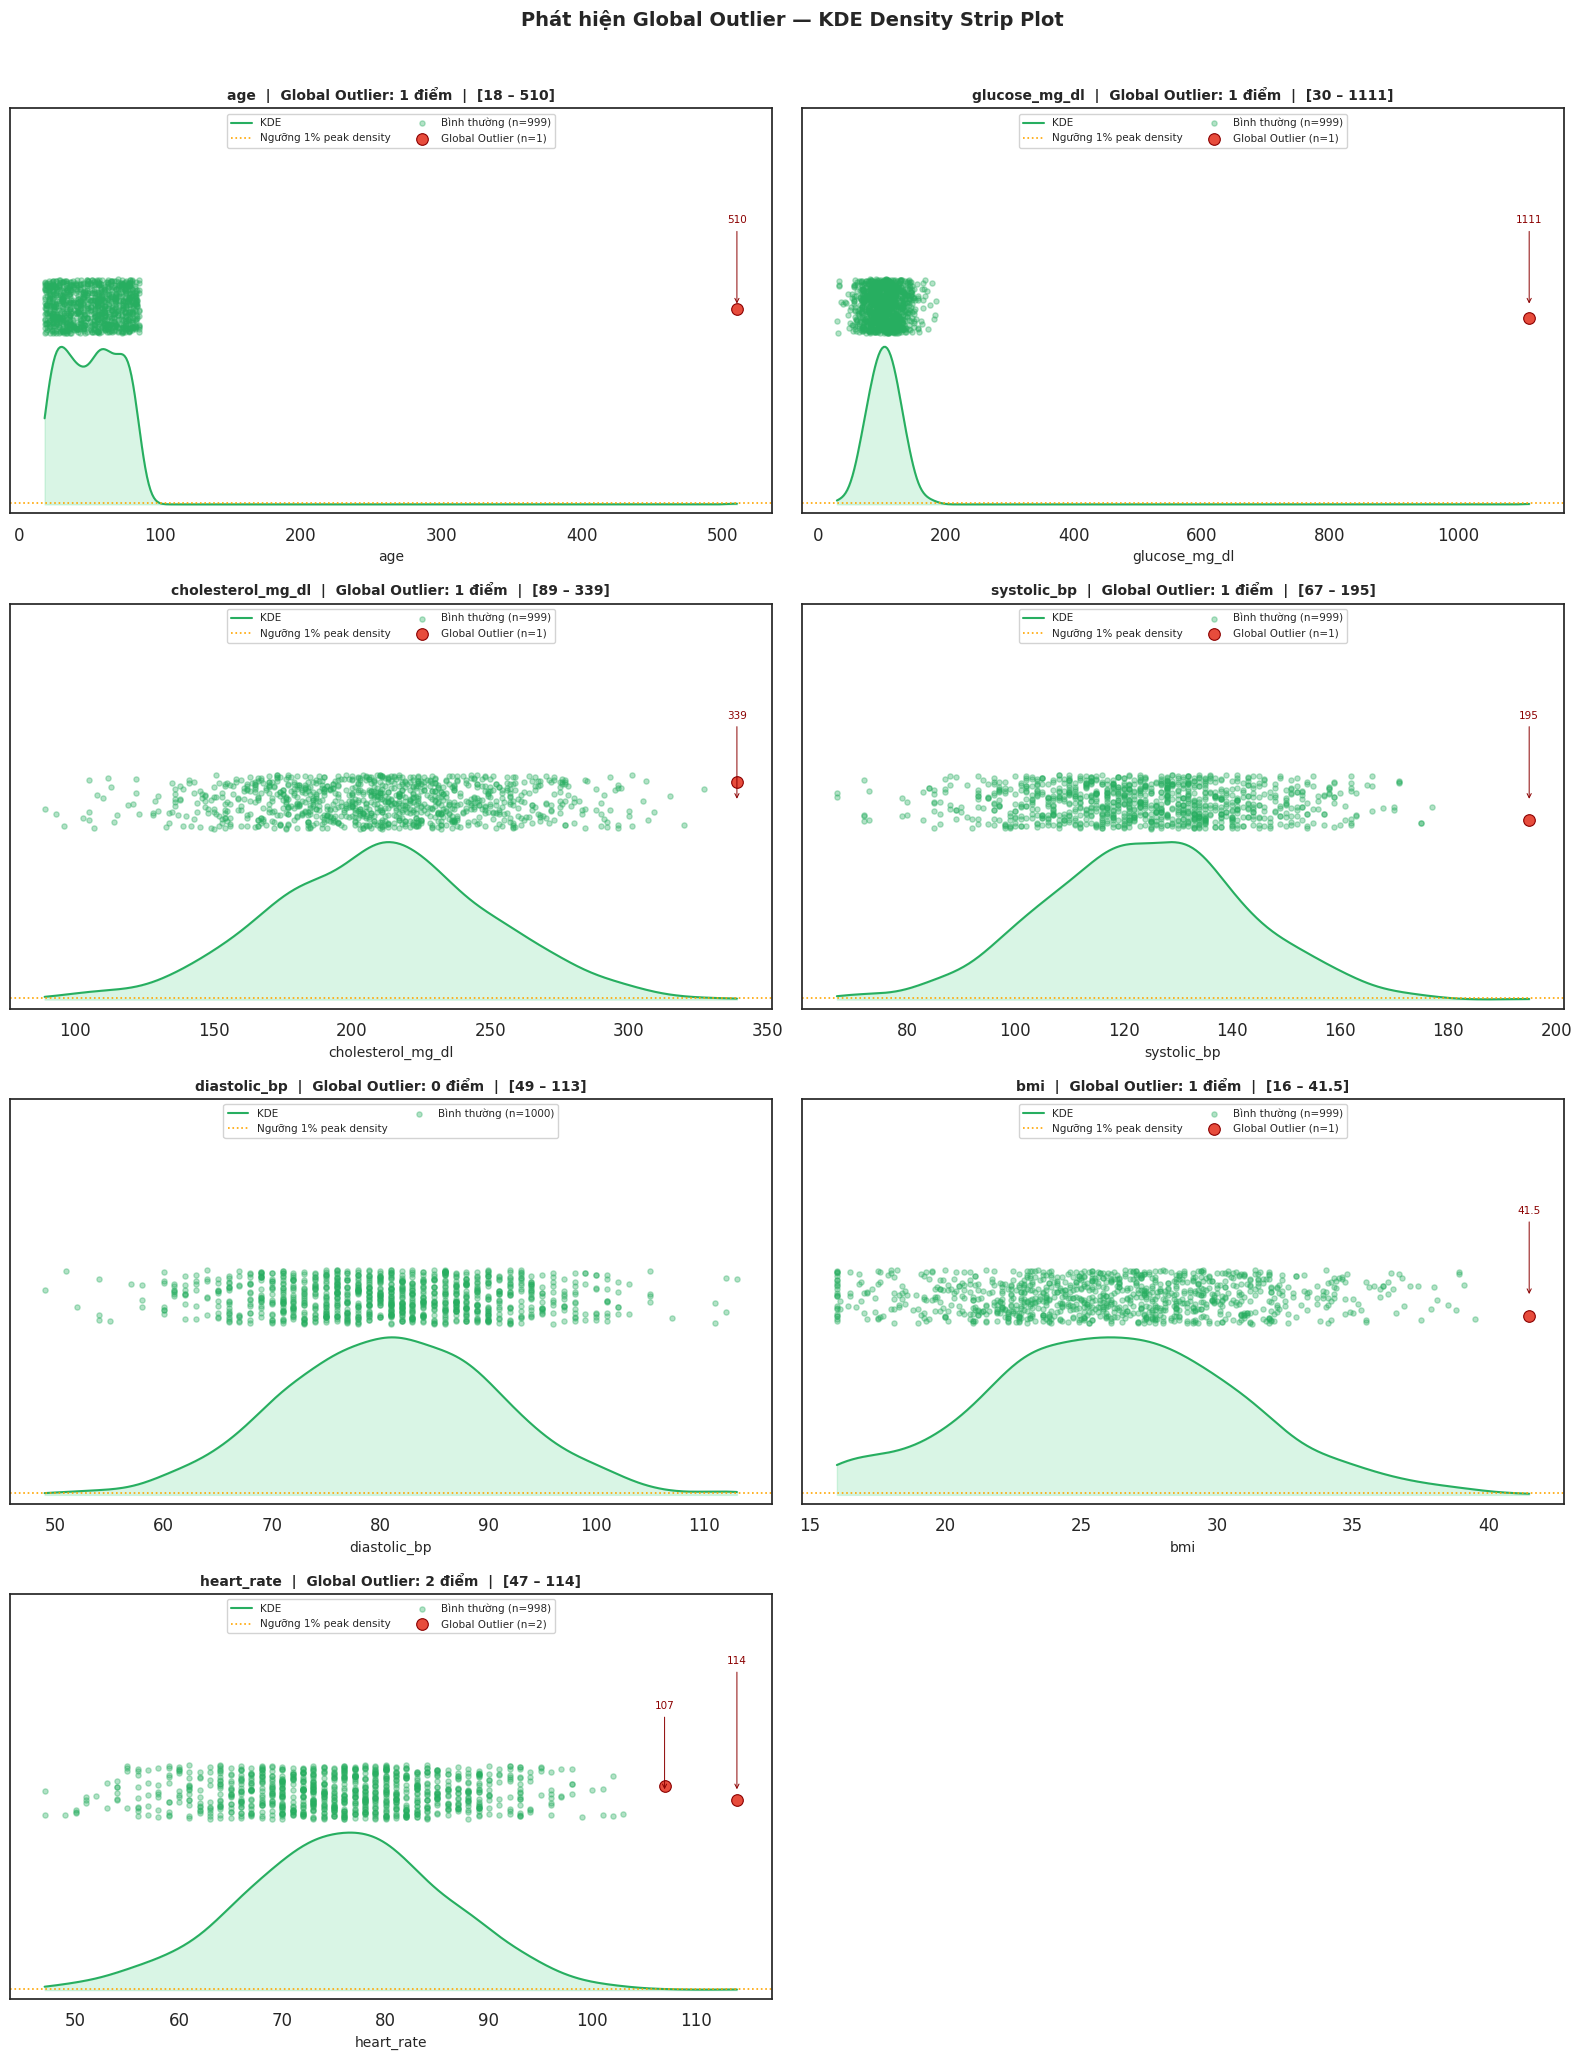


── BẢNG TÓM TẮT GLOBAL OUTLIER (KDE, ngưỡng 1% peak density) ──
Cột                           Min        Max   # Outliers  Giá trị bất thường
------------------------------------------------------------------------------------------
age                            18        510            1  [510.0]
glucose_mg_dl                  30       1111            1  [1111.0]
cholesterol_mg_dl              89        339            1  [339.0]
systolic_bp                    67        195            1  [195.0]
diastolic_bp                   49        113            0  —
bmi                            16       41.5            1  [41.5]
heart_rate                     47        114            2  [107.0, 114.0]


In [10]:
# ── Phát hiện Global Outlier bằng KDE Density (dữ liệu gốc, sau khi điền missing)
from scipy.stats import gaussian_kde
_df_raw_num = df.select_dtypes(include=['float64', 'int64'])
_df_raw_num['diastolic_bp'] = _df_raw_num['diastolic_bp'].fillna(_df_raw_num['diastolic_bp'].median())
_df_raw_num['heart_rate']   = _df_raw_num['heart_rate'].fillna(_df_raw_num['heart_rate'].median())

num_cols_outlier = ['age', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
                    'diastolic_bp', 'bmi', 'heart_rate']

# Ngưỡng: điểm có mật độ KDE < DENSITY_THRESH * peak_density => global outlier
DENSITY_THRESH = 0.01

n_num = len(num_cols_outlier)
fig, axes = plt.subplots(int(np.ceil(n_num / 2)), 2,
                         figsize=(16, n_num * 3.0),
                         constrained_layout=False)
axes = axes.flatten()
np.random.seed(42)

outlier_summary = {}

for i, col in enumerate(num_cols_outlier):
    ax = axes[i]
    series = _df_raw_num[col].dropna().values.astype(float)

    # Ước tính KDE
    kde = gaussian_kde(series, bw_method='scott')
    densities = kde(series)                    # mật độ tại mỗi điểm dữ liệu
    peak_density = densities.max()
    is_outlier = densities < DENSITY_THRESH * peak_density

    inlier_vals  = series[~is_outlier]
    outlier_vals = series[is_outlier]
    outlier_summary[col] = outlier_vals

    # ── Vẽ đường KDE (chuẩn hoá về [0, 1] trên trục y để cùng không gian với strip)
    x_range = np.linspace(series.min(), series.max(), 400)
    kde_curve = kde(x_range)
    kde_norm  = kde_curve / kde_curve.max()    # chuẩn hoá về 1
    ax.fill_between(x_range, kde_norm * 0.35, alpha=0.18, color='#2ecc71')
    ax.plot(x_range, kde_norm * 0.35, color='#27ae60', linewidth=1.5, label='KDE')

    # Đường ngưỡng mật độ (DENSITY_THRESH)
    thresh_y = DENSITY_THRESH * 0.35            # tương ứng trên trục đã chuẩn hoá
    ax.axhline(thresh_y, color='orange', linestyle=':', linewidth=1.2,
               label=f'Ngưỡng {DENSITY_THRESH*100:.0f}% peak density')

    # ── Strip plot: inliers (xanh)
    jitter_in  = np.random.uniform(0.38, 0.50, len(inlier_vals))
    ax.scatter(inlier_vals, jitter_in, alpha=0.35, s=14,
               color='#27ae60', zorder=3, label=f'Bình thường (n={len(inlier_vals)})')

    # ── Strip plot: outliers (đỏ) + annotation giá trị
    if len(outlier_vals) > 0:
        jitter_out = np.random.uniform(0.38, 0.50, len(outlier_vals))
        ax.scatter(outlier_vals, jitter_out, color='#e74c3c', s=70, zorder=5,
                   edgecolors='darkred', linewidths=0.8,
                   label=f'Global Outlier (n={len(outlier_vals)})')

        # Ghi giá trị — tránh chồng chéo bằng cách offset xen kẽ
        unique_out = np.unique(outlier_vals)
        for k, val in enumerate(unique_out):
            y_txt = 0.62 + (k % 2) * 0.10          # xen kẽ 2 hàng
            ax.annotate(f'{val:.4g}',
                        xy=(val, 0.44), xytext=(val, y_txt),
                        fontsize=7.5, color='darkred', ha='center', va='bottom',
                        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.7),
                        zorder=6)

    ax.set_ylim(-0.02, 0.88)
    ax.set_yticks([])
    ax.set_xlabel(col, fontsize=10)
    ax.set_title(f"{col}  |  Global Outlier: {len(outlier_vals)} điểm  |  "
                 f"[{series.min():.4g} – {series.max():.4g}]",
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=7.5, loc='upper center', ncol=2,
              bbox_to_anchor=(0.5, 1.0), framealpha=0.85)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Phát hiện Global Outlier — KDE Density Strip Plot",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ── Bảng tóm tắt
print(f"\n── BẢNG TÓM TẮT GLOBAL OUTLIER (KDE, ngưỡng {DENSITY_THRESH*100:.0f}% peak density) ──")
print(f"{'Cột':<22} {'Min':>10} {'Max':>10} {'# Outliers':>12}  Giá trị bất thường")
print("-" * 90)
for col in num_cols_outlier:
    s = _df_raw_num[col].dropna().values.astype(float)
    out_vals = outlier_summary[col]
    vals_str = str(sorted(set(out_vals.tolist()))) if len(out_vals) > 0 else '—'
    print(f"{col:<22} {s.min():>10.4g} {s.max():>10.4g} {len(out_vals):>12}  {vals_str}")


## 2.2. Làm sạch dữ liệu

In [11]:
# 1. Xử lý giá trị khuyết (Điền bằng giá trị trung vị)
df_clean = df.copy()
df_clean['diastolic_bp'] = df_clean['diastolic_bp'].fillna(df_clean['diastolic_bp'].median())
df_clean['heart_rate'] = df_clean['heart_rate'].fillna(df_clean['heart_rate'].median())


# 2. Lọc bỏ các dòng lỗi nhập liệu quá vô lý
df_clean = df_clean[df_clean['age'] <= 140] # Tuổi không thể quá 140
df_clean = df_clean[df_clean['glucose_mg_dl'] <= 400] # Đường huyết 1111 là lỗi, giữ lại <= 400
df_clean['smoking'] = df_clean['smoking'].replace('0', 'No')

# 3. Đồng nhất cột gender (Chuyển 'M' thành 'Male')
df_clean['gender'] = df_clean['gender'].replace({'M': 'Male'})

# 4. Đồng nhất cột smoking
df_clean['smoking'] = df_clean['smoking'].replace({
    0: 'No',
    '0': 'No',
    1: 'Yes',
    '1': 'Yes'
})

In [12]:

# Kiểm tra lại lần cuối để đảm bảo dữ liệu đã sạch 100%
print("--- KIỂM TRA LẠI SAU KHI XỬ LÝ ---")
print("Cột gender:\n", df_clean['gender'].value_counts())
print("-" * 30)
print("Cột smoking:\n", df_clean['smoking'].value_counts())
print("Kích thước dữ liệu sau làm sạch:", df_clean.shape)
print("\n--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT (MISSING VALUES) ---")
print(df_clean.isnull().sum())
print("\n--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ SAU KHI LÀM SẠCH ---")
display(df_clean.describe().T)

--- KIỂM TRA LẠI SAU KHI XỬ LÝ ---
Cột gender:
 gender
Female    504
Male      494
Name: count, dtype: int64
------------------------------
Cột smoking:
 smoking
Yes    501
No     497
Name: count, dtype: int64
Kích thước dữ liệu sau làm sạch: (998, 13)

--- SỐ LƯỢNG GIÁ TRỊ KHUYẾT (MISSING VALUES) ---
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

--- THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ SAU KHI LÀM SẠCH ---


,count,mean,std,min,25%,50%,75%,max
age,998.0,51.217435,19.848721,18.0,33.0,53.0,69.0,85.0
glucose_mg_dl,998.0,104.168337,25.097757,30.0,87.0,105.0,121.0,184.0
cholesterol_mg_dl,998.0,209.977956,39.772617,89.0,183.0,210.5,235.0,339.0
systolic_bp,998.0,123.890782,18.718554,67.0,111.0,124.0,135.0,195.0
diastolic_bp,998.0,81.051102,9.968777,49.0,74.0,81.0,88.0,113.0
bmi,998.0,26.095691,4.761079,16.0,22.9,26.0,29.3,41.5
heart_rate,998.0,75.974950,9.907920,47.0,70.0,76.0,83.0,114.0


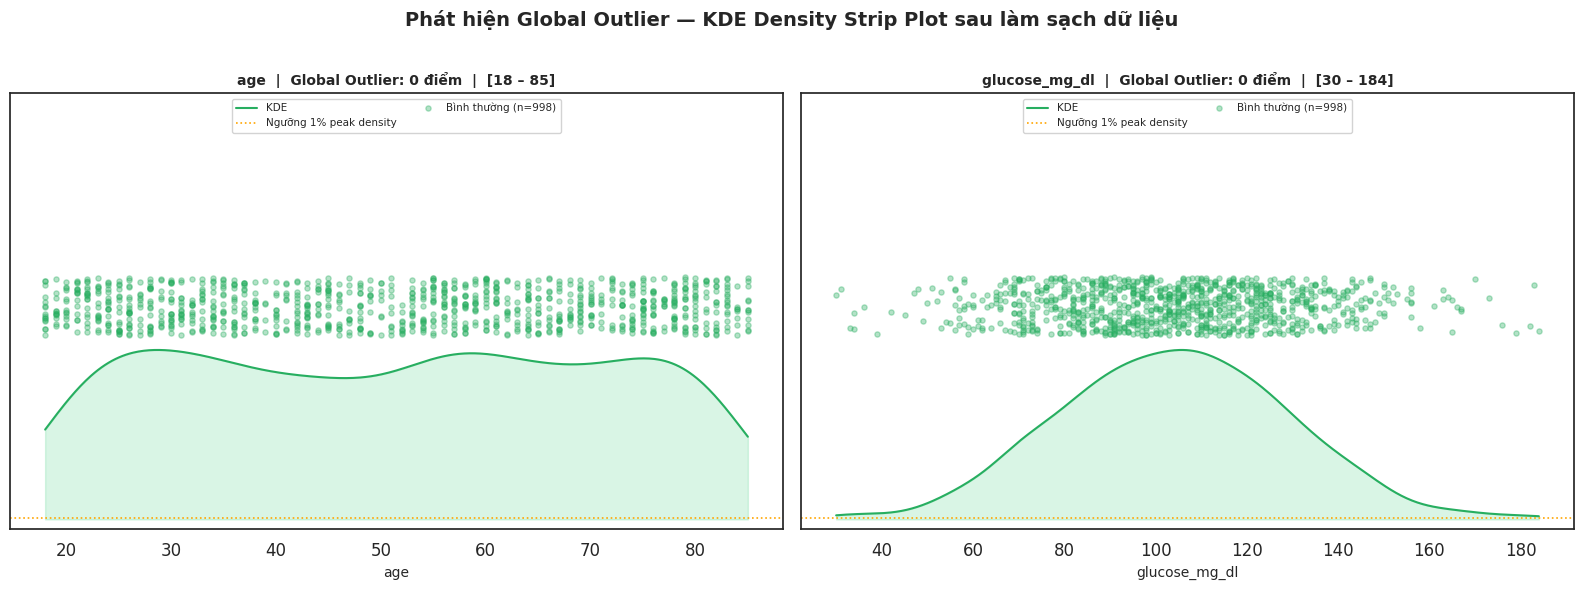


── BẢNG TÓM TẮT GLOBAL OUTLIER (KDE, ngưỡng 1% peak density) ──
Cột                           Min        Max   # Outliers  Giá trị bất thường
------------------------------------------------------------------------------------------
age                            18        510            0  —
glucose_mg_dl                  30       1111            0  —


In [22]:
# Kiểm tra lại KDE sau khi làm sạch
from scipy.stats import gaussian_kde
num_cols_outlier = ['age', 'glucose_mg_dl']


DENSITY_THRESH = 0.01

n_num = len(num_cols_outlier)
fig, axes = plt.subplots(int(np.ceil(n_num / 2)), 2,
                         figsize=(16, n_num * 3.0),
                         constrained_layout=False)
axes = axes.flatten()
np.random.seed(42)

outlier_summary = {}

for i, col in enumerate(num_cols_outlier):
    ax = axes[i]
    series = df_clean[col].dropna().values.astype(float)

    # Ước tính KDE
    kde = gaussian_kde(series, bw_method='scott')
    densities = kde(series)                    # mật độ tại mỗi điểm dữ liệu
    peak_density = densities.max()
    is_outlier = densities < DENSITY_THRESH * peak_density

    inlier_vals  = series[~is_outlier]
    outlier_vals = series[is_outlier]
    outlier_summary[col] = outlier_vals

    # ── Vẽ đường KDE (chuẩn hoá về [0, 1] trên trục y để cùng không gian với strip)
    x_range = np.linspace(series.min(), series.max(), 400)
    kde_curve = kde(x_range)
    kde_norm  = kde_curve / kde_curve.max()    # chuẩn hoá về 1
    ax.fill_between(x_range, kde_norm * 0.35, alpha=0.18, color='#2ecc71')
    ax.plot(x_range, kde_norm * 0.35, color='#27ae60', linewidth=1.5, label='KDE')

    # Đường ngưỡng mật độ (DENSITY_THRESH)
    thresh_y = DENSITY_THRESH * 0.35            # tương ứng trên trục đã chuẩn hoá
    ax.axhline(thresh_y, color='orange', linestyle=':', linewidth=1.2,
               label=f'Ngưỡng {DENSITY_THRESH*100:.0f}% peak density')

    # ── Strip plot: inliers (xanh)
    jitter_in  = np.random.uniform(0.38, 0.50, len(inlier_vals))
    ax.scatter(inlier_vals, jitter_in, alpha=0.35, s=14,
               color='#27ae60', zorder=3, label=f'Bình thường (n={len(inlier_vals)})')

    # ── Strip plot: outliers (đỏ) + annotation giá trị
    if len(outlier_vals) > 0:
        jitter_out = np.random.uniform(0.38, 0.50, len(outlier_vals))
        ax.scatter(outlier_vals, jitter_out, color='#e74c3c', s=70, zorder=5,
                   edgecolors='darkred', linewidths=0.8,
                   label=f'Global Outlier (n={len(outlier_vals)})')

        # Ghi giá trị — tránh chồng chéo bằng cách offset xen kẽ
        unique_out = np.unique(outlier_vals)
        for k, val in enumerate(unique_out):
            y_txt = 0.62 + (k % 2) * 0.10          # xen kẽ 2 hàng
            ax.annotate(f'{val:.4g}',
                        xy=(val, 0.44), xytext=(val, y_txt),
                        fontsize=7.5, color='darkred', ha='center', va='bottom',
                        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.7),
                        zorder=6)

    ax.set_ylim(-0.02, 0.88)
    ax.set_yticks([])
    ax.set_xlabel(col, fontsize=10)
    ax.set_title(f"{col}  |  Global Outlier: {len(outlier_vals)} điểm  |  "
                 f"[{series.min():.4g} – {series.max():.4g}]",
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=7.5, loc='upper center', ncol=2,
              bbox_to_anchor=(0.5, 1.0), framealpha=0.85)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Phát hiện Global Outlier — KDE Density Strip Plot sau làm sạch dữ liệu",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ── Bảng tóm tắt
print(f"\n── BẢNG TÓM TẮT GLOBAL OUTLIER (KDE, ngưỡng {DENSITY_THRESH*100:.0f}% peak density) ──")
print(f"{'Cột':<22} {'Min':>10} {'Max':>10} {'# Outliers':>12}  Giá trị bất thường")
print("-" * 90)
for col in num_cols_outlier:
    s = _df_raw_num[col].dropna().values.astype(float)
    out_vals = outlier_summary[col]
    vals_str = str(sorted(set(out_vals.tolist()))) if len(out_vals) > 0 else '—'
    print(f"{col:<22} {s.min():>10.4g} {s.max():>10.4g} {len(out_vals):>12}  {vals_str}")


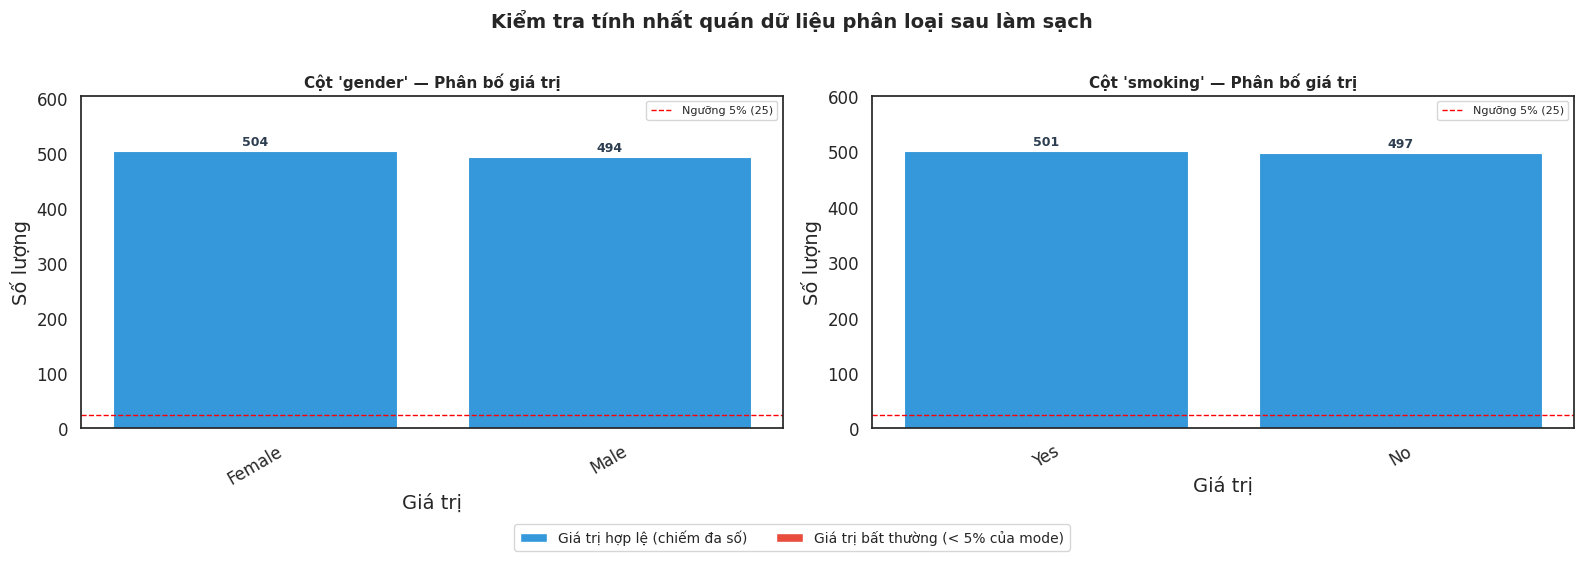


--- TÓM TẮT CÁC GIÁ TRỊ BẤT THƯỜNG PHÁT HIỆN ---
  [gender]: Giá trị bất thường: {'M': np.int64(2)}
  [smoking]: Giá trị bất thường: {'1': np.int64(1), '0': np.int64(1)}


In [14]:
# Biểu đồ kiểm tra tính nhất quán dữ liệu phân loại trên dữ liệu sau khi làm sạch
from matplotlib.patches import Patch

raw_cat_cols = ['gender', 'smoking']

n_cat = len(raw_cat_cols)
fig, axes = plt.subplots(int(np.ceil(n_cat / 2)), 2,
                         figsize=(16, n_cat * 2.8),
                         constrained_layout=False)
axes = axes.flatten()

for i, col in enumerate(raw_cat_cols):
    ax = axes[i]
    vc = df_clean[col].value_counts(dropna=False).sort_values(ascending=False)
    threshold = vc.max() * 0.05  # Các giá trị < 5% của mode => bất thường

    colors = ['#e74c3c' if v < threshold else '#3498db' for v in vc.values]
    bars = ax.bar(vc.index.astype(str), vc.values, color=colors,
                  edgecolor='white', linewidth=0.8)

    # Tính ylim với padding 20% phía trên để text số không bị cắt
    max_val = vc.max()
    ax.set_ylim(0, max_val * 1.20)

    # Ghi số lượng lên đầu mỗi thanh (căn chỉnh bên trong khoảng padding)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.01,
                str(val), ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#2c3e50')

    ax.set_title(f"Cột '{col}' — Phân bố giá trị", fontweight='bold', fontsize=11)
    ax.set_xlabel("Giá trị")
    ax.set_ylabel("Số lượng")
    ax.tick_params(axis='x', rotation=30)

    # Đường ngưỡng 5%
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1,
               label=f'Ngưỡng 5% ({threshold:.0f})')
    ax.legend(fontsize=8, loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Legend chung ở dưới cùng
legend_elements = [
    Patch(facecolor='#3498db', label='Giá trị hợp lệ (chiếm đa số)'),
    Patch(facecolor='#e74c3c', label='Giá trị bất thường (< 5% của mode)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.0))

plt.suptitle("Kiểm tra tính nhất quán dữ liệu phân loại sau làm sạch",
             fontsize=14, fontweight='bold')
# rect=(left, bottom, right, top): để chừa chỗ cho suptitle trên và legend dưới
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

# In tóm tắt bằng text
print("\n--- TÓM TẮT CÁC GIÁ TRỊ BẤT THƯỜNG PHÁT HIỆN ---")
for col in raw_cat_cols:
    vc = df[col].value_counts(dropna=False).sort_values(ascending=False)
    threshold = vc.max() * 0.05
    anomalies = vc[vc < threshold]
    if len(anomalies) > 0:
        print(f"  [{col}]: Giá trị bất thường: {dict(anomalies)}")
    else:
        print(f"  [{col}]: OK — Không có giá trị bất thường")

# Phần 3. Phân tích các thuộc tính


## 3.1. Phân tích biến mục tiêu (nhãn)

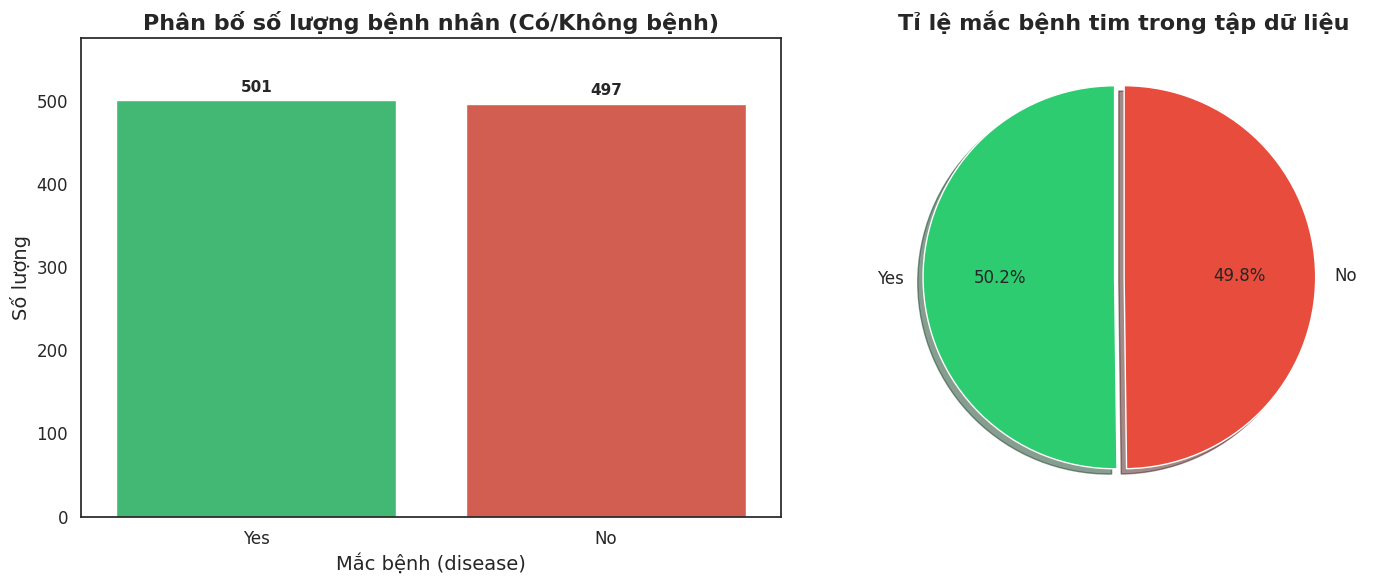

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ đếm (Count plot)
sns.countplot(data=df_clean, x='disease', palette=palette_disease, ax=ax[0])
ax[0].set_title("Phân bố số lượng bệnh nhân (Có/Không bệnh)")
ax[0].set_xlabel("Mắc bệnh (disease)")
ax[0].set_ylabel("Số lượng")

# Thêm count label trên đầu mỗi cột
_max0 = max(p.get_height() for p in ax[0].patches)
ax[0].set_ylim(0, _max0 * 1.15)
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=11, fontweight='bold',
                   xytext=(0, 4), textcoords='offset points')

# Biểu đồ tròn (Pie chart)
disease_counts = df_clean['disease'].value_counts()
ax[1].pie(disease_counts, labels=disease_counts.index, autopct='%1.1f%%',
          colors=palette_disease, startangle=90, explode=(0.05, 0), shadow=True)
ax[1].set_title("Tỉ lệ mắc bệnh tim trong tập dữ liệu")

plt.tight_layout()
plt.show()


## 3.2. Phân tích thuộc tính liên tục

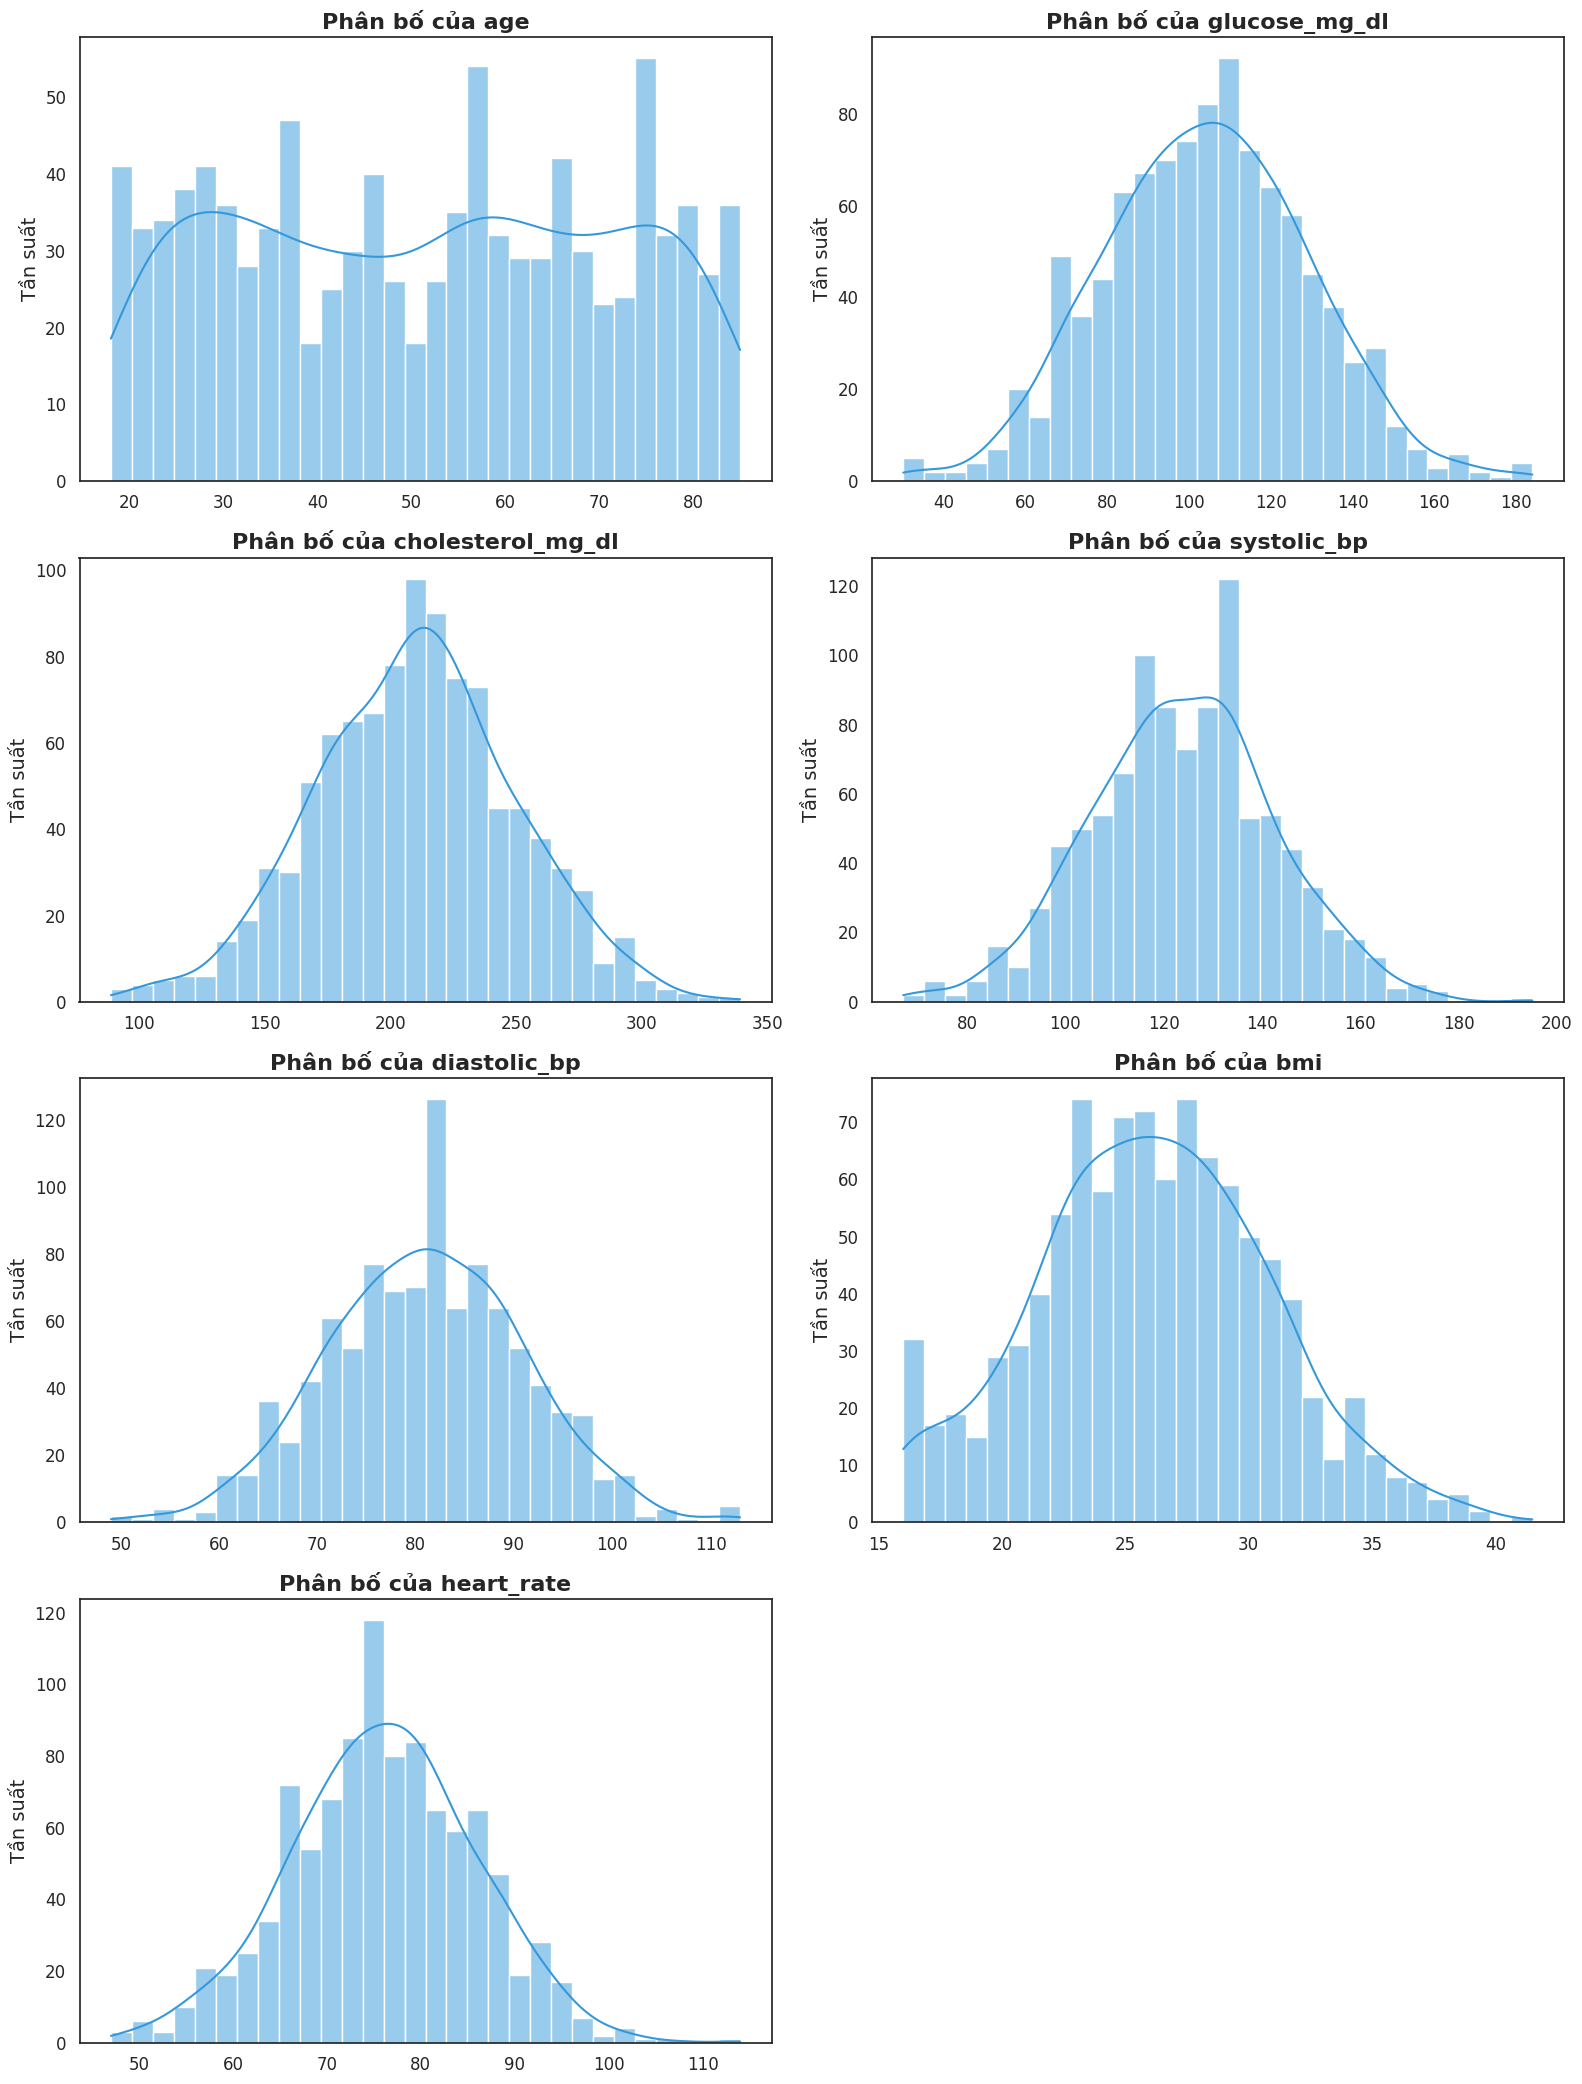

In [16]:
# Tự động tạo lưới biểu đồ dựa trên số lượng cột số
n_cols = len(num_cols)
fig, axes = plt.subplots(int(np.ceil(n_cols/2)), 2, figsize=(16, n_cols * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='#3498db', bins=30)
    axes[i].set_title(f"Phân bố của {col}", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Tần suất")

# Xóa các trục trống nếu số lượng cột lẻ
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3.3. Phân tích thuộc tính phân loại

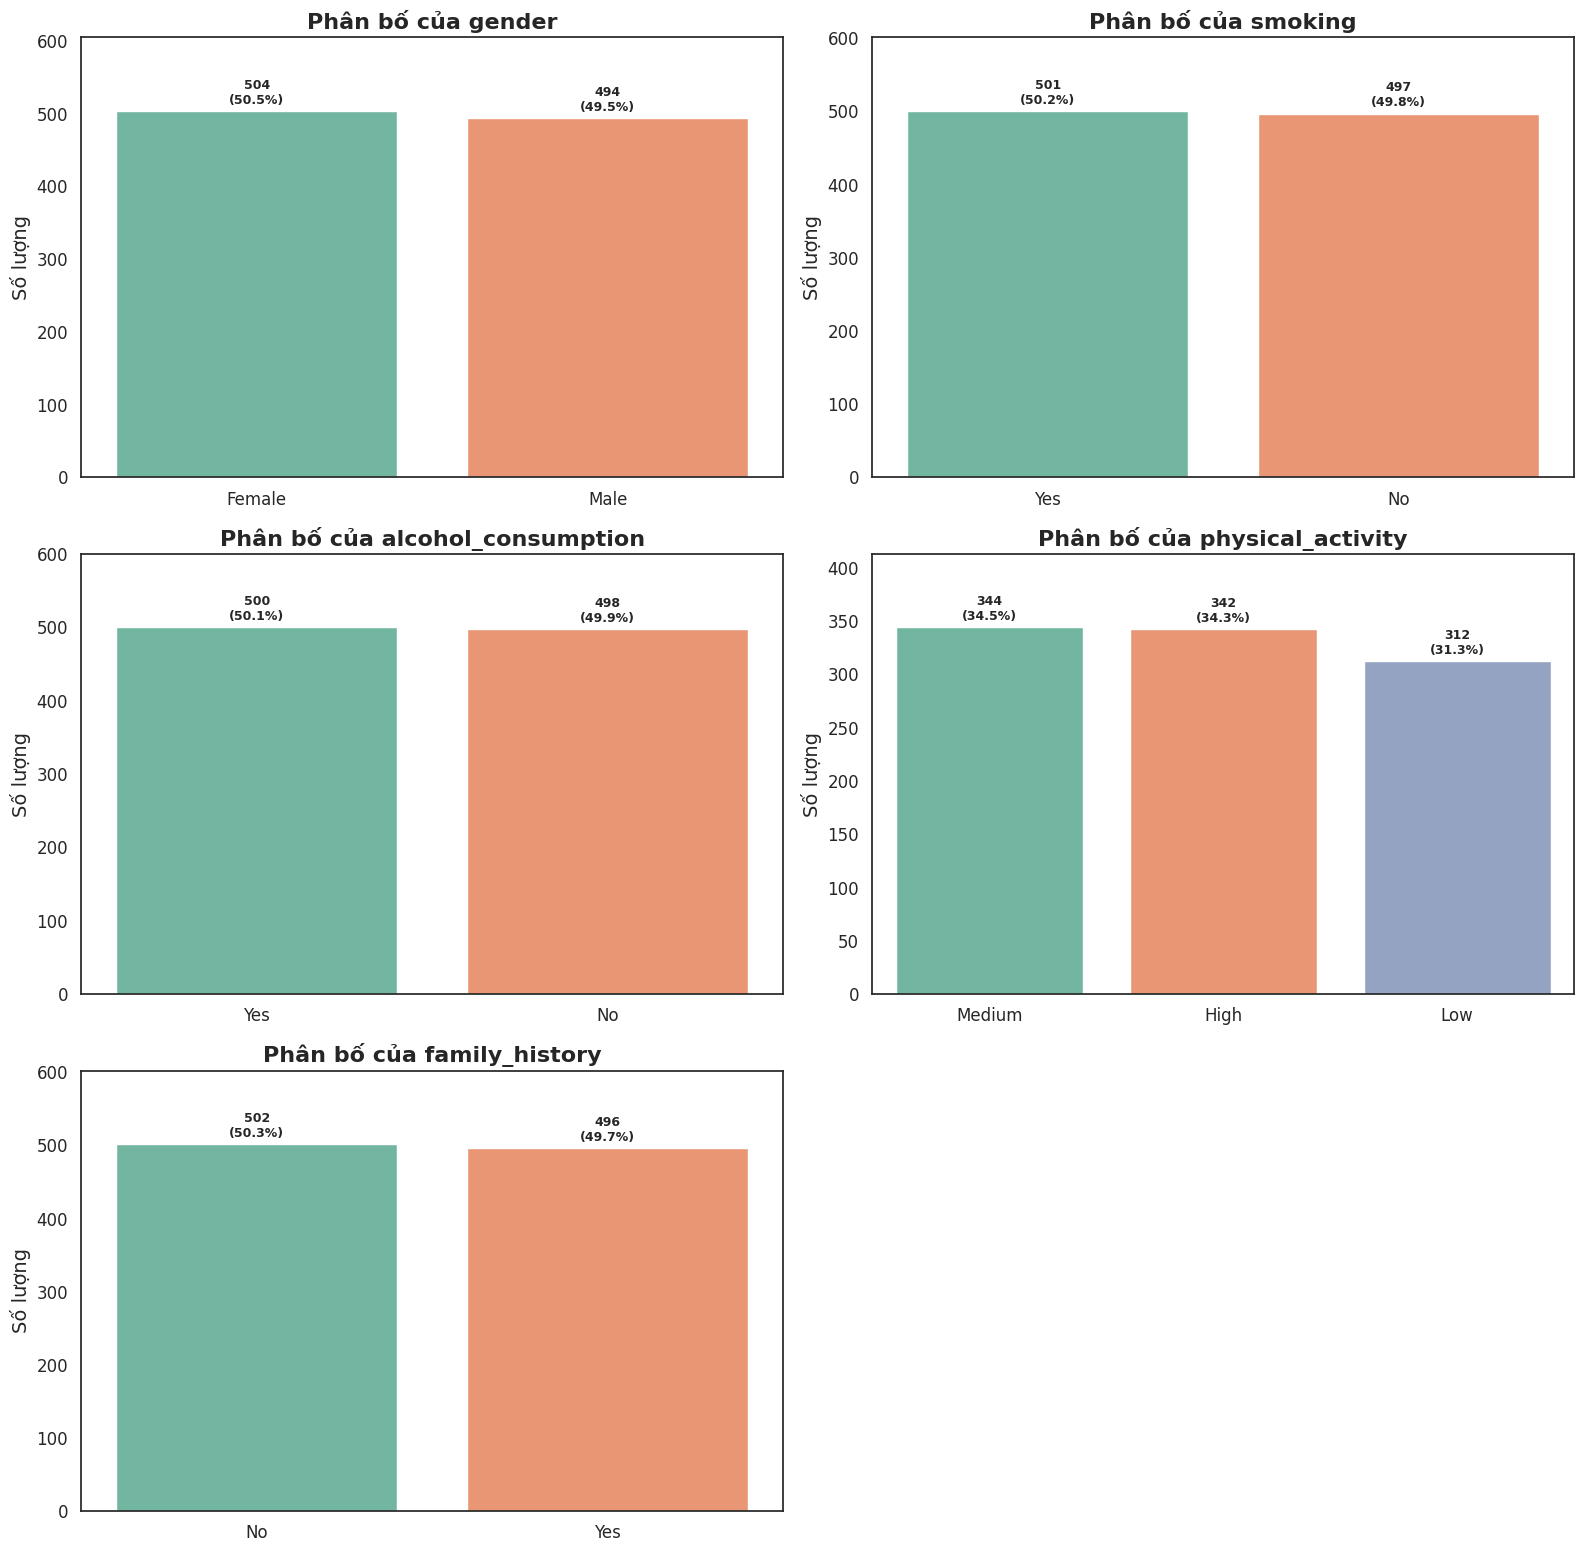

In [17]:
# Tự động tạo lưới biểu đồ dựa trên số lượng cột phân loại
n_cols = len(cat_cols)
fig, axes = plt.subplots(int(np.ceil(n_cols/2)), 2, figsize=(16, n_cols * 3.2))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, palette=palette_set2, ax=axes[i], order=order)
    axes[i].set_title(f"Phân bố của {col}", fontweight='bold')
    axes[i].set_ylabel("Số lượng")
    axes[i].set_xlabel("")

    total = len(df_clean[col].dropna())

    # Count + tỉ lệ % trên đầu mỗi cột
    _max_h = max((p.get_height() for p in axes[i].patches), default=0)
    axes[i].set_ylim(0, _max_h * 1.20)
    for p in axes[i].patches:
        h = p.get_height()
        if h > 0:
            axes[i].annotate(f'{int(h)}\n({h/total*100:.1f}%)',
                             (p.get_x() + p.get_width() / 2., h),
                             ha='center', va='bottom', fontsize=9, fontweight='bold',
                             xytext=(0, 3), textcoords='offset points')

fig.delaxes(axes[-1])  # Xóa ô biểu đồ trống cuối cùng
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 3.4. Mối tương quan giữa chỉ số y khoa và bệnh tim

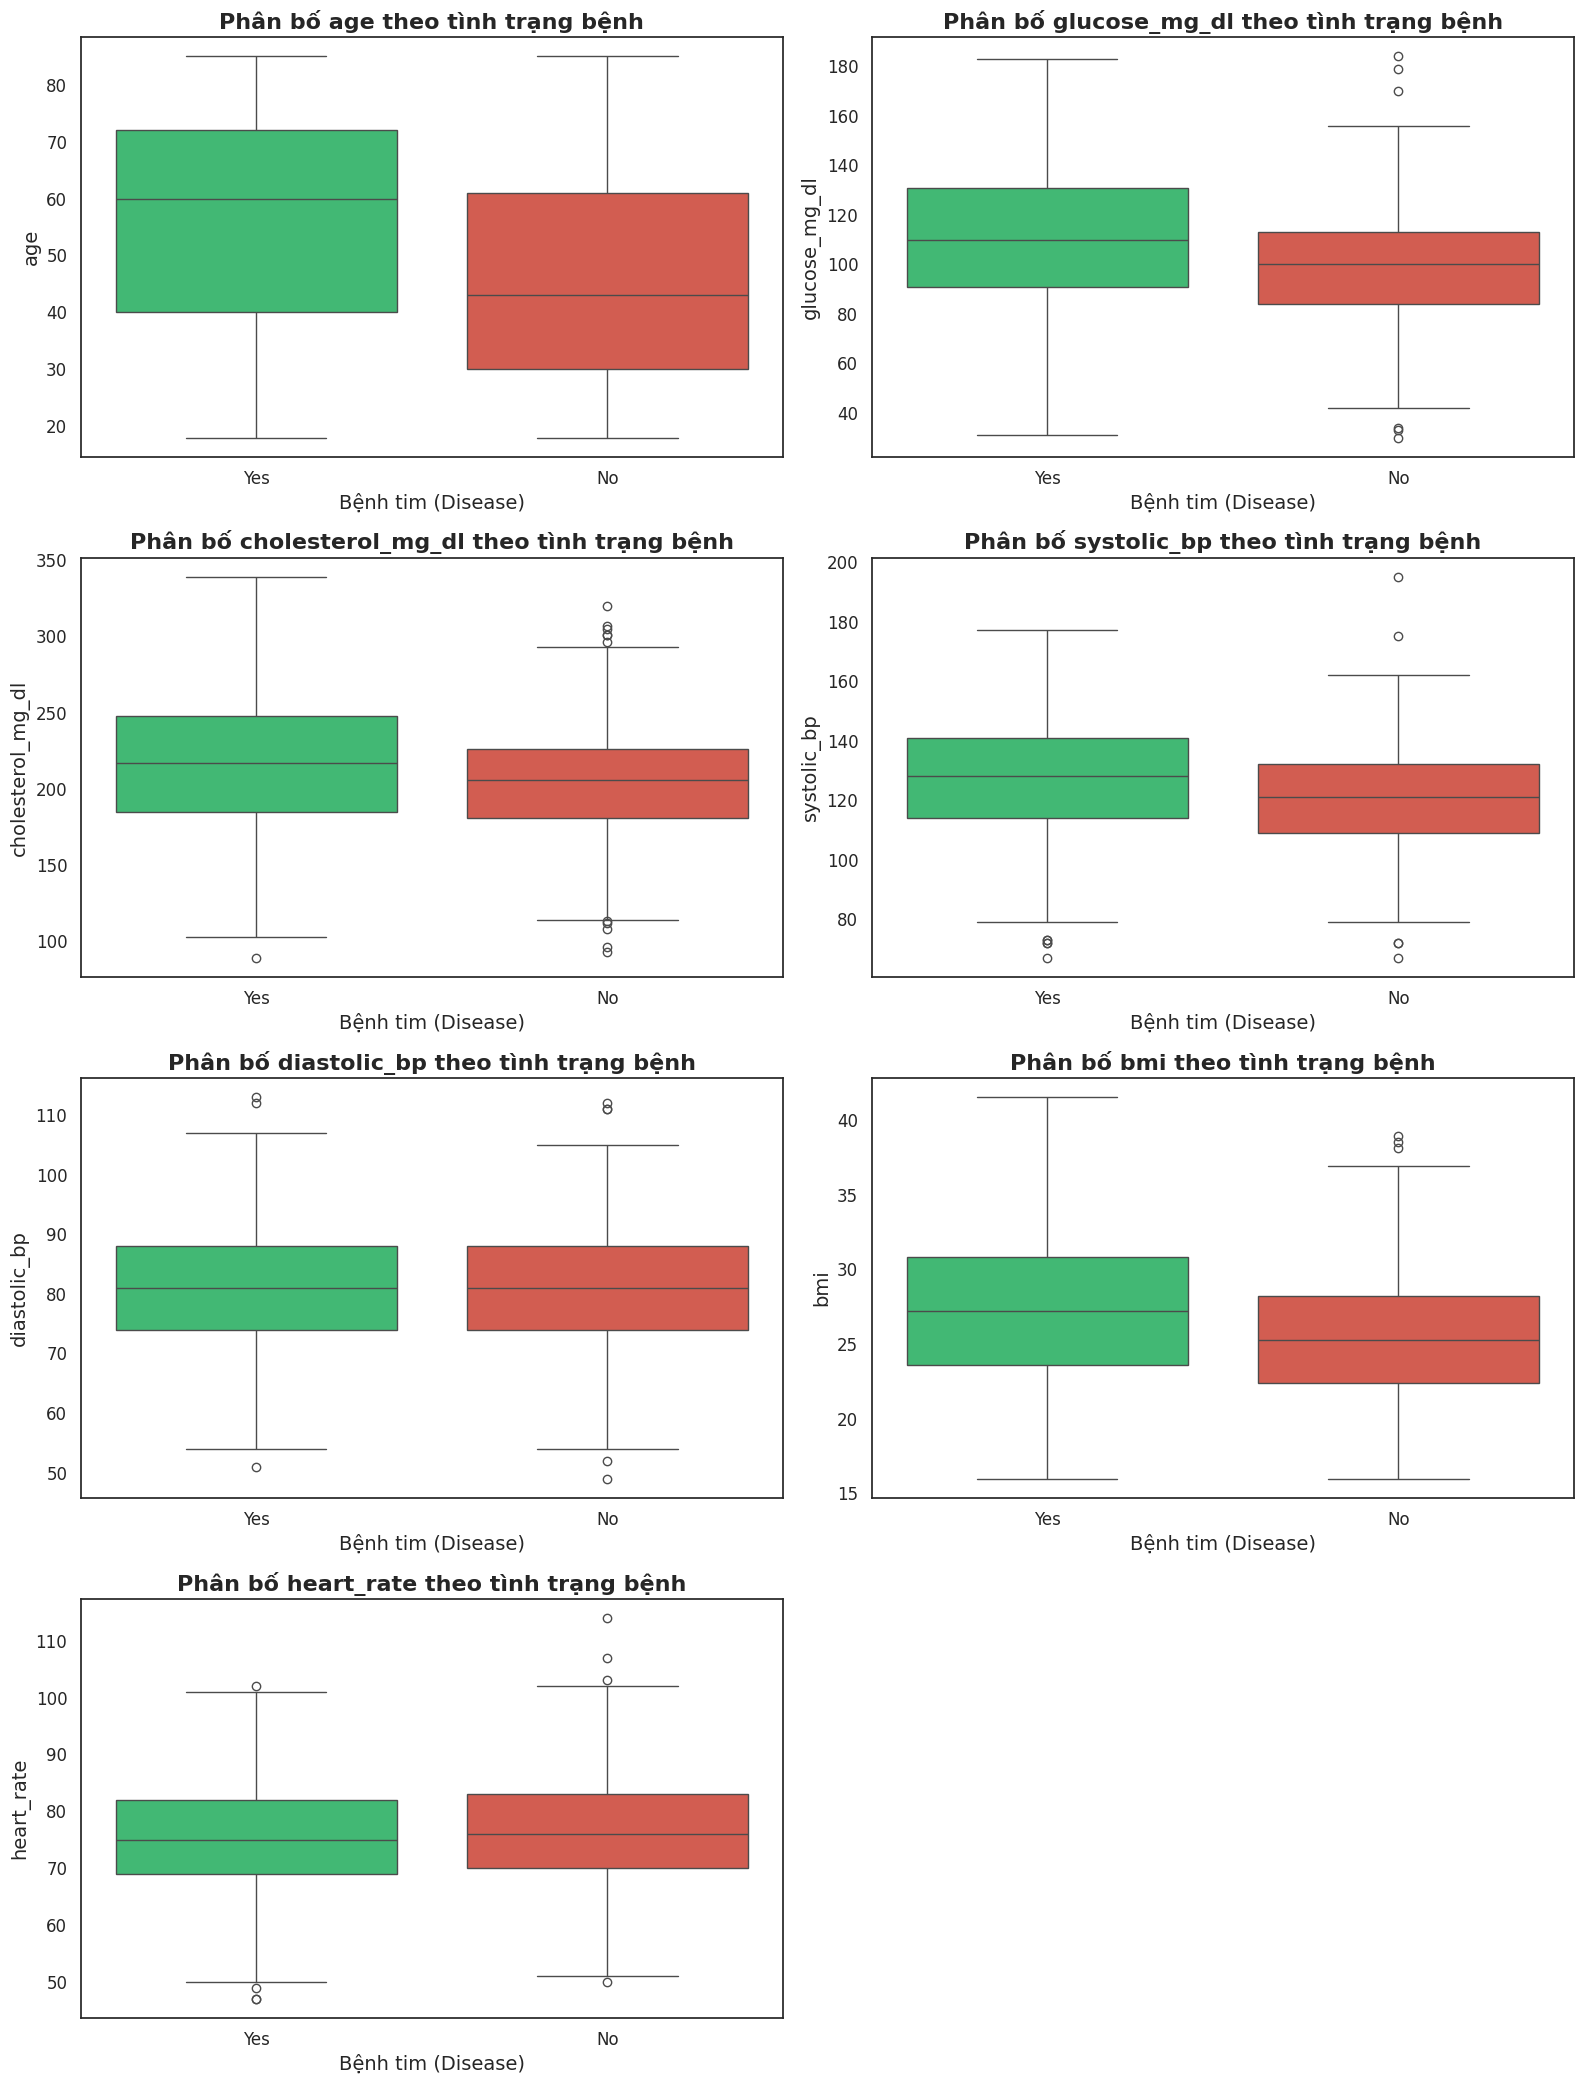

In [18]:
# Tự động tạo lưới biểu đồ dựa trên số lượng cột số
n_cols = len(num_cols)
fig, axes = plt.subplots(int(np.ceil(n_cols/2)), 2, figsize=(16, n_cols * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='disease', y=col, palette=palette_disease, ax=axes[i])
    axes[i].set_title(f"Phân bố {col} theo tình trạng bệnh", fontweight='bold')
    axes[i].set_xlabel("Bệnh tim (Disease)")
    axes[i].set_ylabel(col)

# Xóa các ô thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3.5. Mối tương quan giữa lối sống và bệnh tim

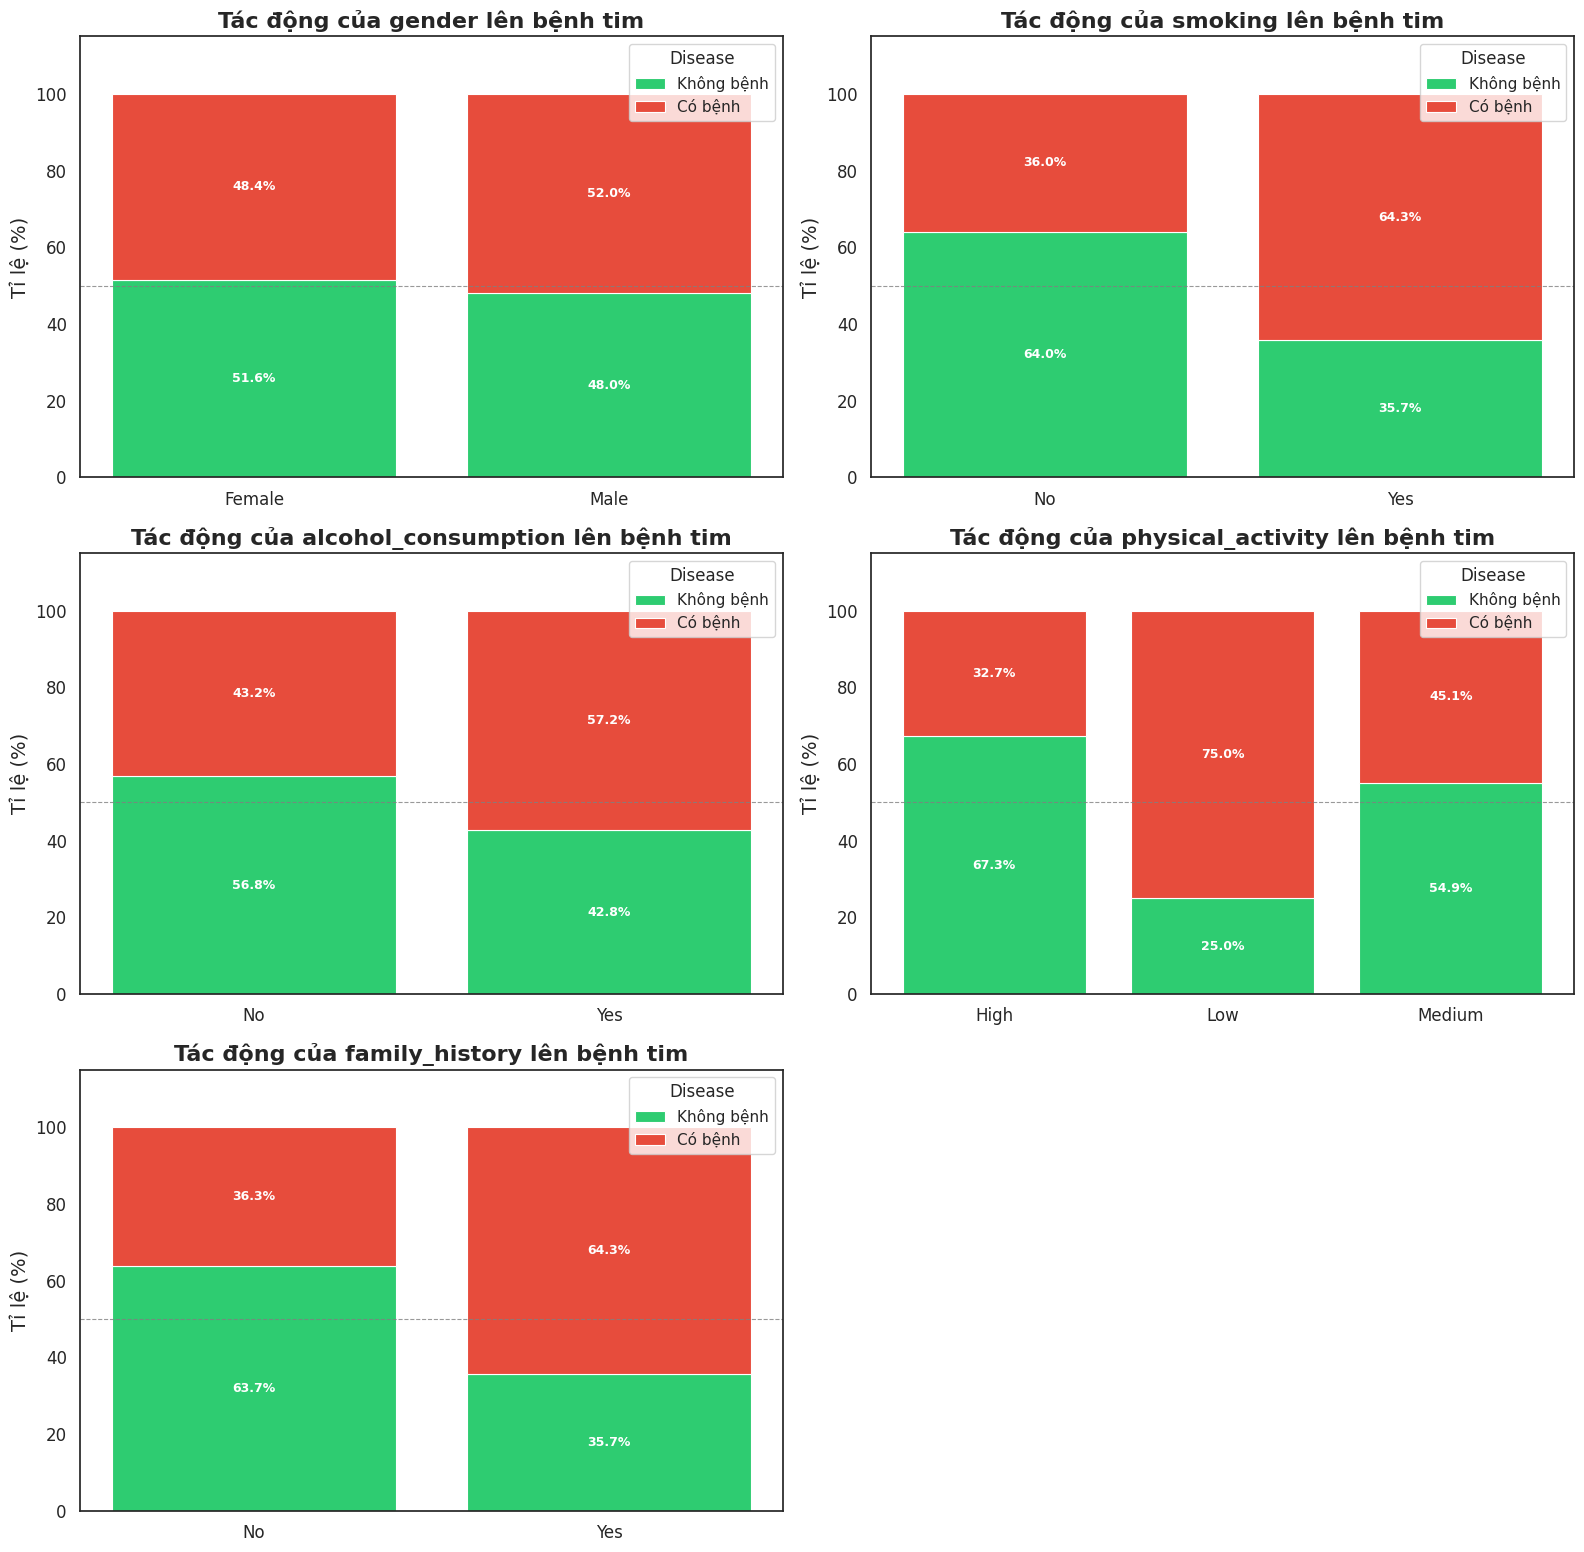

In [19]:
# Tự động tạo lưới biểu đồ 100% Stacked Bar dựa trên số lượng cột phân loại
n_cols = len(cat_cols)
fig, axes = plt.subplots(int(np.ceil(n_cols / 2)), 2, figsize=(16, n_cols * 3.2))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Tính tỉ lệ Disease=Yes/No trong từng nhóm
    prop = (df_clean.groupby([col, 'disease'], observed=True)
                    .size()
                    .unstack(fill_value=0))
    for label in ['No', 'Yes']:
        if label not in prop.columns:
            prop[label] = 0
    prop = prop[['No', 'Yes']]
    prop_pct = prop.div(prop.sum(axis=1), axis=0) * 100

    categories = prop_pct.index.tolist()
    no_vals  = prop_pct['No'].values
    yes_vals = prop_pct['Yes'].values
    x = range(len(categories))

    ax.bar(x, no_vals,  color=palette_disease[0], label='Không bệnh', edgecolor='white', linewidth=0.8)
    ax.bar(x, yes_vals, color=palette_disease[1], label='Có bệnh',    edgecolor='white', linewidth=0.8,
           bottom=no_vals)

    # Label tỉ lệ % bên trong từng đoạn
    for j, (nv, yv) in enumerate(zip(no_vals, yes_vals)):
        if nv > 6:
            ax.text(j, nv / 2,      f'{nv:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        if yv > 6:
            ax.text(j, nv + yv / 2, f'{yv:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')

    ax.set_xticks(list(x))
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 115)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
    ax.set_title(f"Tác động của {col} lên bệnh tim", fontweight='bold')
    ax.set_ylabel("Tỉ lệ (%)")
    ax.set_xlabel("")
    ax.legend(title='Disease', loc='upper right')

# Xóa ô thừa nếu n_cols lẻ
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 3.5. Ma trận tương quan giữa các thuộc tính

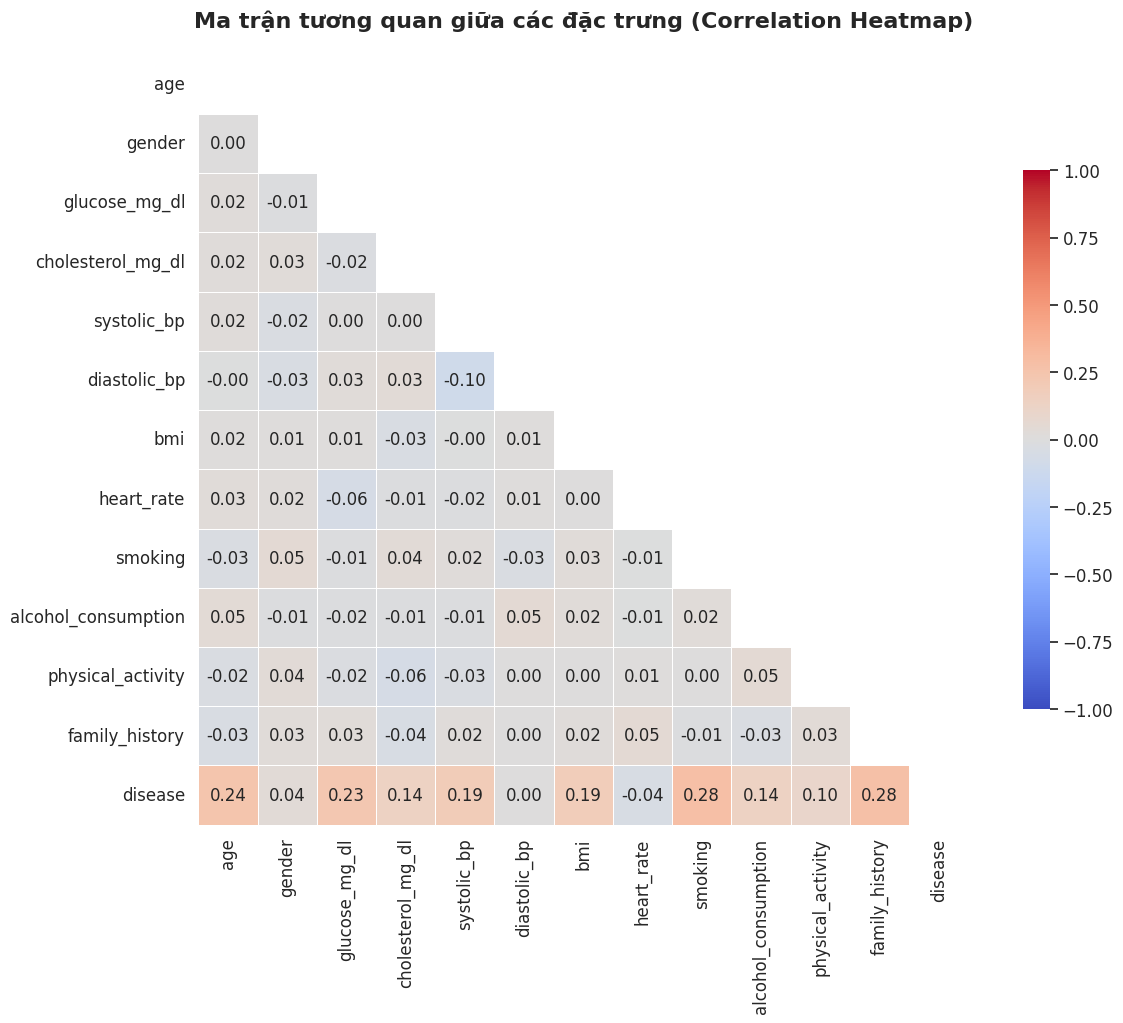

In [20]:
# Tạo một bản sao dữ liệu để mã hóa tạm thời tất cả các biến số
df_corr = df_clean.copy()

# Mã hóa Label Encoding tự động cho tất cả các cột chữ (bao gồm cả disease)
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

plt.figure(figsize=(14, 10))
# Tính toán ma trận tương quan (Pearson)
corr_matrix = df_corr.corr()

# Vẽ Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Che nửa trên của ma trận
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title("Ma trận tương quan giữa các đặc trưng (Correlation Heatmap)", pad=20)
plt.show()

# Phần 4. Lưu lại dữ liệu đã làm sạch cho bước train

In [21]:
df_clean.to_csv('/content/drive/MyDrive/Data Mining/Project/disease_prediction_2026_clean.csv', index=False)
print("Đã lưu dữ liệu được làm sạch thành công!")

Đã lưu dữ liệu được làm sạch thành công!
